# NYC Taxi Trip Duration — ANN Regression Pipeline

Predict how long a New York City taxi trip will take, using an **Artificial Neural Network**.

**Task:** regression — given pickup time and pickup/dropoff coordinates, predict `trip_duration` (seconds).

**Official metric:** RMSLE (Root Mean Squared *Logarithmic* Error), so we train on `log1p(duration)`.

---

## Project timeline

| Phase | Work | Est. time |
|---|---|---|
| **1. Setup** | Download data, load, first look | 30 min |
| **2. EDA** | Target distribution, outliers, coordinate spread | 1–2 hrs |
| **3. Cleaning** | Remove leakage, clip outliers & bad coordinates | 1 hr |
| **4. Feature engineering** | Haversine/Manhattan distance, bearing, datetime parts, KMeans zones | 2–3 hrs |
| **5. Preprocessing** | Scale numerics, one-hot categoricals, log-transform target | 1 hr |
| **6. Baseline** | Ridge regression — the number the ANN must beat | 30 min |
| **7. Build ANN** | Architecture, compile | 1 hr |
| **8. Train** | Early stopping, LR scheduling | 1–2 hrs (compute) |
| **9. Evaluate** | RMSLE, RMSE, MAE, R², residual plots | 1 hr |
| **10. Save & predict** | Artifacts + inference function | 30 min |
| | **Total** | **~2–3 days** part-time |

---

## Pipeline

1. Load the data
2. EDA — understand the target
3. **Remove leakage** and clean outliers ⚠️
4. Feature engineering (this is where the project is won)
5. Train/validation split + preprocessing
6. Baseline model
7. Build the ANN
8. Train
9. Evaluate
10. Save artifacts + predict a new trip

> ⚠️ **The critical cell is Step 3.** `dropoff_datetime` minus `pickup_datetime` *is* the target. If you leave it in, you get a "perfect" model that is worthless.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.cluster import MiniBatchKMeans
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

print("TensorFlow:", tf.__version__)

TensorFlow: 2.21.0


## 1. Load the data

From the Kaggle competition *nyc-taxi-trip-duration*. We only need `train.csv` — it has the
labels. (`test.csv` is unlabelled, for competition submission only.)

In [2]:
df = pd.read_csv(r"C:\Users\Bhargav\Downloads\DATASETS\NYC.csv")
print("Shape:", df.shape)
df.head(3)

Shape: (1458644, 11)


,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,455
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,663
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N,2124


In [3]:
df.info()
print("\nMissing values:", df.isna().sum().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1458644 entries, 0 to 1458643
Data columns (total 11 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   id                  1458644 non-null  object 
 1   vendor_id           1458644 non-null  int64  
 2   pickup_datetime     1458644 non-null  object 
 3   dropoff_datetime    1458644 non-null  object 
 4   passenger_count     1458644 non-null  int64  
 5   pickup_longitude    1458644 non-null  float64
 6   pickup_latitude     1458644 non-null  float64
 7   dropoff_longitude   1458644 non-null  float64
 8   dropoff_latitude    1458644 non-null  float64
 9   store_and_fwd_flag  1458644 non-null  object 
 10  trip_duration       1458644 non-null  int64  
dtypes: float64(4), int64(3), object(4)
memory usage: 122.4+ MB

Missing values: 0


In [5]:
df.duplicated().sum()

np.int64(0)

## 2. EDA — understand the target

`trip_duration` is in **seconds** and is wildly skewed: most trips are ~10 minutes, but a few
claim to last *days*. Those are data errors. This skew is exactly why the competition scores
on RMSLE and why we train on `log1p`.

count    1.458644e+06
mean     9.594923e+02
std      5.237432e+03
min      1.000000e+00
25%      3.970000e+02
50%      6.620000e+02
75%      1.075000e+03
max      3.526282e+06
Name: trip_duration, dtype: float64

Max duration in DAYS: 40.81344907407407
Trips over 3 hours: 2112
Trips under 10 sec : 1984


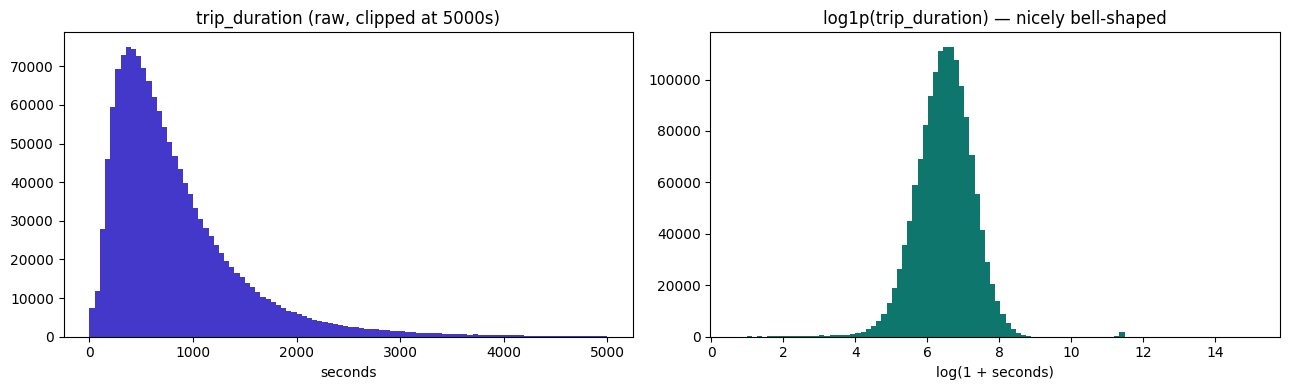

In [6]:
dur = df["trip_duration"]

print(dur.describe())
print("\nMax duration in DAYS:", dur.max() / 86400)
print("Trips over 3 hours:", (dur > 3 * 3600).sum())
print("Trips under 10 sec :", (dur < 10).sum())

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(dur[dur < 5000], bins=100, color="#4338CA")
axes[0].set_title("trip_duration (raw, clipped at 5000s)")
axes[0].set_xlabel("seconds")

axes[1].hist(np.log1p(dur), bins=100, color="#0F766E")
axes[1].set_title("log1p(trip_duration) — nicely bell-shaped")
axes[1].set_xlabel("log(1 + seconds)")

plt.tight_layout(); plt.show()

## 3. Remove leakage and clean outliers ⚠️

**Leakage.** `dropoff_datetime` is only known *after* the trip ends. `dropoff - pickup` is
literally the target. It must go — along with `id`, which carries no signal.

**Outliers.** We drop physically impossible trips and coordinates outside New York.

In [7]:
# --- 3a. Parse datetimes ---
df["pickup_datetime"] = pd.to_datetime(df["pickup_datetime"])

# --- 3b. DROP LEAKAGE ---
LEAKAGE = ["dropoff_datetime"]   
USELESS = ["id"]

drop_cols = [c for c in LEAKAGE + USELESS if c in df.columns]
df = df.drop(columns=drop_cols)
print("Dropped:", drop_cols)

Dropped: ['dropoff_datetime', 'id']


In [8]:
# --- 3c. Filter impossible trips ---
before = len(df)

# Duration: keep 1 minute .. 3 hours
df = df[(df["trip_duration"] >= 60) & (df["trip_duration"] <= 3 * 3600)]

# Passengers: 1..6 (0 passengers is a data error)
df = df[df["passenger_count"].between(1, 6)]

# Coordinates: inside a New York City bounding box
NYC = dict(lon_min=-74.30, lon_max=-73.70, lat_min=40.50, lat_max=40.95)
for pre in ["pickup", "dropoff"]:
    df = df[df[f"{pre}_longitude"].between(NYC["lon_min"], NYC["lon_max"])]
    df = df[df[f"{pre}_latitude"].between(NYC["lat_min"], NYC["lat_max"])]

print(f"Removed {before - len(df):,} rows ({(before-len(df))/before:.2%})")
print(f"Remaining: {len(df):,}")

Removed 11,668 rows (0.80%)
Remaining: 1,446,976


## 4. Feature engineering — where this project is won

The raw data gives four coordinates and a timestamp. On their own, an ANN cannot do much with
them. We turn them into features with real meaning:

**Distance features**
- **Haversine** — great-circle ("as the crow flies") distance in km
- **Manhattan** — a better proxy for a grid-based city like NYC
- **Bearing** — the compass direction of travel (captures e.g. airport runs)

**Time features** — hour, weekday, month, plus rush-hour and weekend flags.
Hour is *cyclical* (23:00 is adjacent to 00:00), so we encode it with sine/cosine.

**Zone features** — KMeans clusters the coordinates into pickup/dropoff neighbourhoods.

In [9]:
def haversine(lat1, lon1, lat2, lon2):
    """Great-circle distance in km."""
    R = 6371.0
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    return 2 * R * np.arcsin(np.sqrt(a))


def manhattan(lat1, lon1, lat2, lon2):
    """Grid distance: horizontal leg + vertical leg (fits NYC's street grid)."""
    a = haversine(lat1, lon1, lat1, lon2)   # east-west leg
    b = haversine(lat1, lon1, lat2, lon1)   # north-south leg
    return a + b


def bearing(lat1, lon1, lat2, lon2):
    """Compass direction of travel, in degrees."""
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlon = lon2 - lon1
    y = np.sin(dlon) * np.cos(lat2)
    x = np.cos(lat1) * np.sin(lat2) - np.sin(lat1) * np.cos(lat2) * np.cos(dlon)
    return np.degrees(np.arctan2(y, x))


def add_features(d):
    d = d.copy()
    plat, plon = d["pickup_latitude"], d["pickup_longitude"]
    dlat, dlon = d["dropoff_latitude"], d["dropoff_longitude"]

    # --- distance ---
    d["dist_haversine"] = haversine(plat, plon, dlat, dlon)
    d["dist_manhattan"] = manhattan(plat, plon, dlat, dlon)
    d["bearing"] = bearing(plat, plon, dlat, dlon)

    # --- time ---
    ts = d["pickup_datetime"]
    d["hour"] = ts.dt.hour
    d["weekday"] = ts.dt.weekday          # 0 = Monday
    d["month"] = ts.dt.month
    d["day_of_year"] = ts.dt.dayofyear
    d["is_weekend"] = (d["weekday"] >= 5).astype(int)
    d["is_rush_hour"] = d["hour"].isin([7, 8, 9, 16, 17, 18, 19]).astype(int)

    # hour is cyclical: 23:00 is next to 00:00
    d["hour_sin"] = np.sin(2 * np.pi * d["hour"] / 24)
    d["hour_cos"] = np.cos(2 * np.pi * d["hour"] / 24)

    d = d.drop(columns=["pickup_datetime"])
    return d


df = add_features(df)
print("Features now:", df.shape[1])
df.head(3)

Features now: 19


,vendor_id,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,dist_haversine,dist_manhattan,bearing,hour,weekday,month,day_of_year,is_weekend,is_rush_hour,hour_sin,hour_cos
0,2,1,-73.982155,40.767937,-73.964630,40.765602,N,455,1.498521,1.735433,99.970196,17,0,3,74,0,1,-0.965926,-0.258819
1,1,1,-73.980415,40.738564,-73.999481,40.731152,N,663,1.805507,2.430506,-117.153768,0,6,6,164,1,0,0.000000,1.000000
2,2,1,-73.979027,40.763939,-74.005333,40.710087,N,2124,6.385098,8.203575,-159.680165,11,1,1,19,0,0,0.258819,-0.965926


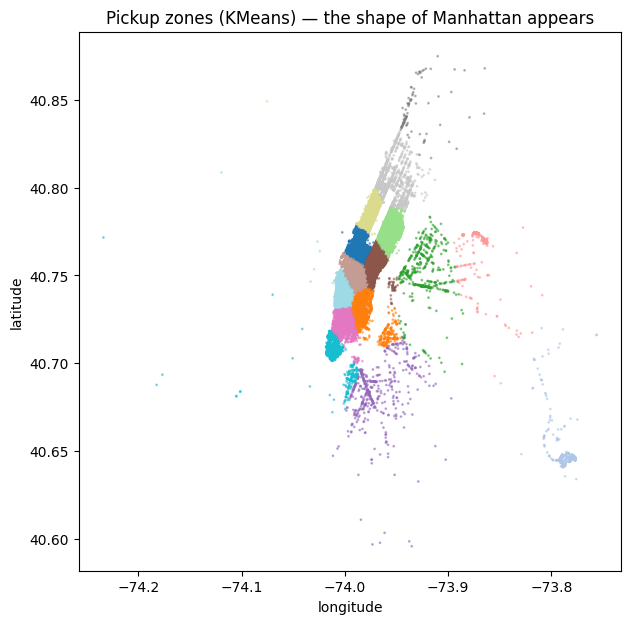

In [10]:
# --- KMeans zones: cluster coordinates into neighbourhoods ---
# Fit on pickup AND dropoff points together so the zone ids mean the same thing for both.
coords = np.vstack([
    df[["pickup_latitude", "pickup_longitude"]].values,
    df[["dropoff_latitude", "dropoff_longitude"]].values,
])

kmeans = MiniBatchKMeans(n_clusters=15, batch_size=10_000,
                         random_state=RANDOM_STATE, n_init="auto").fit(coords)

df["pickup_zone"] = kmeans.predict(df[["pickup_latitude", "pickup_longitude"]].values)
df["dropoff_zone"] = kmeans.predict(df[["dropoff_latitude", "dropoff_longitude"]].values)

# treat zone ids as categories, not numbers (zone 7 isn't "more" than zone 3)
df["pickup_zone"] = df["pickup_zone"].astype(str)
df["dropoff_zone"] = df["dropoff_zone"].astype(str)

plt.figure(figsize=(7, 7))
sample = df.sample(min(50_000, len(df)), random_state=RANDOM_STATE)
plt.scatter(sample["pickup_longitude"], sample["pickup_latitude"],
            c=sample["pickup_zone"].astype(int), s=1, cmap="tab20", alpha=0.5)
plt.title("Pickup zones (KMeans) — the shape of Manhattan appears")
plt.xlabel("longitude"); plt.ylabel("latitude")
plt.show()

## 5. Target transform, split, and preprocessing

**Target:** train on `log1p(trip_duration)`. Minimising MSE on the log target is exactly
minimising RMSLE — the competition metric — and it stops long trips from dominating the loss.

We split **before** fitting the scaler so the model never peeks at validation data.

In [11]:
y = np.log1p(df["trip_duration"])            # <-- log target
X = df.drop(columns=["trip_duration"])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print("Train:", X_train.shape, " Test:", X_test.shape)

Train: (1157580, 20)  Test: (289396, 20)


In [12]:
num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X_train.select_dtypes(exclude=[np.number]).columns.tolist()

print(f"{len(num_cols)} numeric, {len(cat_cols)} categorical")
print("Numeric    :", num_cols)
print("Categorical:", cat_cols)

preprocessor = ColumnTransformer([
    ("num", Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler()),
    ]), num_cols),
    ("cat", Pipeline([
        ("impute", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ]), cat_cols),
])

X_train_prep = np.asarray(preprocessor.fit_transform(X_train), dtype="float32")
X_test_prep = np.asarray(preprocessor.transform(X_test), dtype="float32")

n_features = X_train_prep.shape[1]
print("\nFeatures after encoding:", n_features)

17 numeric, 3 categorical
Numeric    : ['vendor_id', 'passenger_count', 'pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude', 'dist_haversine', 'dist_manhattan', 'bearing', 'hour', 'weekday', 'month', 'day_of_year', 'is_weekend', 'is_rush_hour', 'hour_sin', 'hour_cos']
Categorical: ['store_and_fwd_flag', 'pickup_zone', 'dropoff_zone']

Features after encoding: 49


## 6. Baseline — the number the ANN must beat

Always build a dumb baseline first. If the neural network can't beat a linear model,
something is wrong with the network, not the data.

In [13]:
def rmsle_from_log(y_log_true, y_log_pred):
    """Both inputs are already in log space, so this is just RMSE there."""
    return float(np.sqrt(mean_squared_error(y_log_true, y_log_pred)))


ridge = Ridge(alpha=1.0).fit(X_train_prep, y_train)
ridge_pred = ridge.predict(X_test_prep)

baseline_rmsle = rmsle_from_log(y_test, ridge_pred)
print(f"Ridge baseline RMSLE: {baseline_rmsle:.4f}")

Ridge baseline RMSLE: 0.4961


## 7. Build the ANN

A feedforward regressor:
- ReLU hidden layers, **linear output** (regression — no sigmoid!)
- BatchNorm to stabilise, Dropout to regularise
- Loss = **MSE on the log target** (= RMSLE on the real target)

In [14]:
def build_ann(n_features):
    model = Sequential([
        Input(shape=(n_features,)),

        Dense(256, activation="relu"),
        BatchNormalization(),
        Dropout(0.2),

        Dense(128, activation="relu"),
        BatchNormalization(),
        Dropout(0.2),

        Dense(64, activation="relu"),
        Dropout(0.1),

        Dense(1, activation="linear"),      # regression output
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="mse",                          # MSE on log target == RMSLE
        metrics=[tf.keras.metrics.RootMeanSquaredError(name="rmse")],
    )
    return model


model = build_ann(n_features)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 256)                 │          12,800 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 256)                 │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 55,553 (217.00 KB)

 Trainable params: 54,785 (214.00 KB)

 Non-trainable params: 768 (3.00 KB)

## 8. Train

In [15]:
callbacks = [
    EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=4, min_lr=1e-5, verbose=1),
]

history = model.fit(
    X_train_prep, y_train,
    validation_split=0.15,
    epochs=60,
    batch_size=1024,
    callbacks=callbacks,
    verbose=1,
)

Epoch 1/60
961/961 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - loss: 1.4004 - rmse: 1.1834 - val_loss: 0.1679 - val_rmse: 0.4098 - learning_rate: 0.0010
Epoch 2/60
961/961 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - loss: 0.4923 - rmse: 0.7016 - val_loss: 0.1487 - val_rmse: 0.3856 - learning_rate: 0.0010
Epoch 3/60
961/961 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - loss: 0.3974 - rmse: 0.6304 - val_loss: 0.1429 - val_rmse: 0.3780 - learning_rate: 0.0010
Epoch 4/60
961/961 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - loss: 0.3353 - rmse: 0.5790 - val_loss: 0.1377 - val_rmse: 0.3711 - learning_rate: 0.0010
Epoch 5/60
961/961 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - loss: 0.2841 - rmse: 0.5330 - val_loss: 0.1416 - val_rmse: 0.3763 - learning_rate: 0.0010
Epoch 6/60
961/961 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - loss: 0.2454 - rmse: 0.4954 - val_loss: 0.1337 - val_rmse: 0.3656 - learning_rate: 0.0010
Epoch 7/60
961/961 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - loss: 0.2186 - rmse: 0.4676 - val_loss: 0.1250 - val_rmse: 0.3535 - 

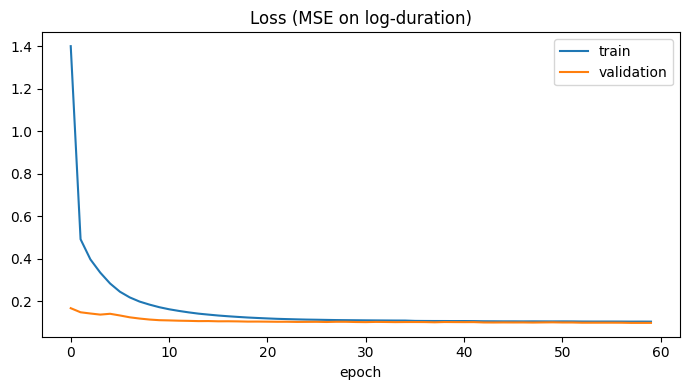

In [16]:
h = history.history
plt.figure(figsize=(7, 4))
plt.plot(h["loss"], label="train")
plt.plot(h["val_loss"], label="validation")
plt.title("Loss (MSE on log-duration)")
plt.xlabel("epoch"); plt.legend()
plt.tight_layout(); plt.show()

## 9. Evaluate

We report **RMSLE** (the competition metric, in log space) plus **RMSE / MAE in real seconds**,
which is what actually means something to a human.

In [17]:
y_pred_log = model.predict(X_test_prep, verbose=0).ravel()

# --- log space: the competition metric ---
ann_rmsle = rmsle_from_log(y_test, y_pred_log)

# --- back to seconds, for human-readable errors ---
y_true_sec = np.expm1(y_test)
y_pred_sec = np.expm1(y_pred_log)

rmse_sec = float(np.sqrt(mean_squared_error(y_true_sec, y_pred_sec)))
mae_sec = float(mean_absolute_error(y_true_sec, y_pred_sec))
r2 = float(r2_score(y_test, y_pred_log))

print(f"ANN   RMSLE : {ann_rmsle:.4f}")
print(f"Ridge RMSLE : {baseline_rmsle:.4f}   (baseline)")
print(f"Improvement : {(baseline_rmsle - ann_rmsle) / baseline_rmsle:.2%}\n")
print(f"RMSE : {rmse_sec:7.1f} sec  ({rmse_sec/60:.1f} min)")
print(f"MAE  : {mae_sec:7.1f} sec  ({mae_sec/60:.1f} min)")
print(f"R^2  : {r2:.4f}  (on log duration)")

ANN   RMSLE : 0.3134
Ridge RMSLE : 0.4961   (baseline)
Improvement : 36.82%

RMSE :   286.4 sec  (4.8 min)
MAE  :   171.4 sec  (2.9 min)
R^2  : 0.8146  (on log duration)


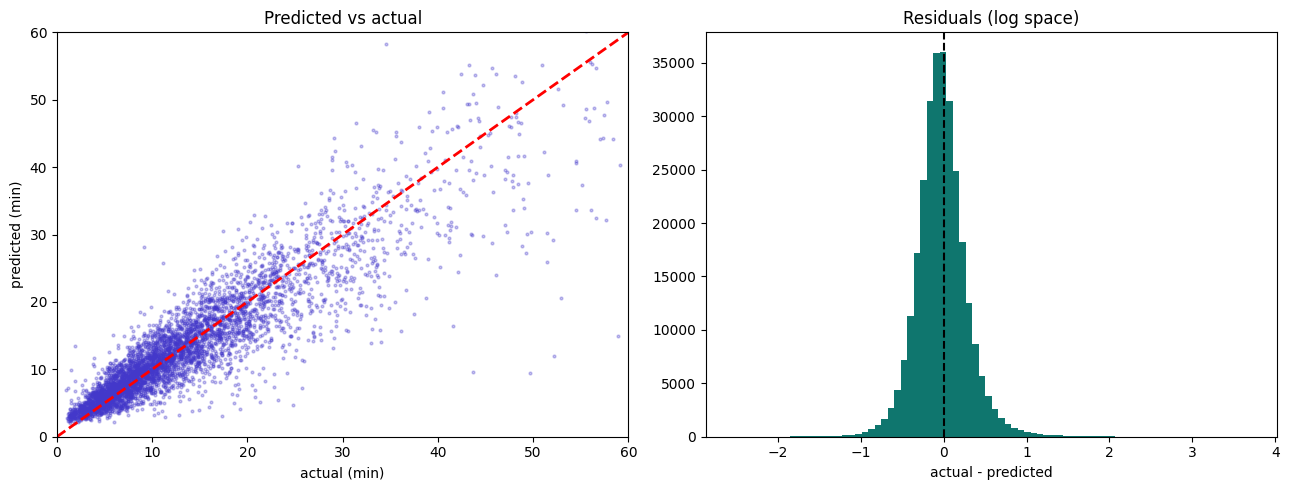

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Predicted vs actual (in minutes)
s = np.random.choice(len(y_true_sec), size=min(5000, len(y_true_sec)), replace=False)
axes[0].scatter(np.asarray(y_true_sec)[s] / 60, y_pred_sec[s] / 60, s=4, alpha=0.3, color="#4338CA")
lim = [0, 60]
axes[0].plot(lim, lim, "r--", lw=2)
axes[0].set_xlim(lim); axes[0].set_ylim(lim)
axes[0].set_xlabel("actual (min)"); axes[0].set_ylabel("predicted (min)")
axes[0].set_title("Predicted vs actual")

# Residuals
resid = np.asarray(y_test) - y_pred_log
axes[1].hist(resid, bins=80, color="#0F766E")
axes[1].axvline(0, color="k", ls="--")
axes[1].set_title("Residuals (log space)"); axes[1].set_xlabel("actual - predicted")

plt.tight_layout(); plt.show()

## 10. Save artifacts and predict a new trip

You need the **model**, the **preprocessor**, and the **KMeans** — a new trip must be transformed
exactly the way training data was.

In [19]:
import joblib

FEATURE_COLS = X_train.columns.tolist()

model.save("taxi_ann_model.keras")
joblib.dump(preprocessor, "taxi_preprocessor.pkl")
joblib.dump(kmeans, "taxi_kmeans.pkl")
joblib.dump({"columns": FEATURE_COLS}, "taxi_config.pkl")

print("Saved: taxi_ann_model.keras, taxi_preprocessor.pkl, taxi_kmeans.pkl, taxi_config.pkl")

Saved: taxi_ann_model.keras, taxi_preprocessor.pkl, taxi_kmeans.pkl, taxi_config.pkl


In [20]:
def predict_trip(pickup_datetime, pickup_lat, pickup_lon, dropoff_lat, dropoff_lon,
                 passenger_count=1, vendor_id=1, store_and_fwd_flag="N"):
    """Predict trip duration (seconds) for one new taxi trip."""
    row = pd.DataFrame([{
        "vendor_id": vendor_id,
        "pickup_datetime": pd.to_datetime(pickup_datetime),
        "passenger_count": passenger_count,
        "pickup_longitude": pickup_lon,
        "pickup_latitude": pickup_lat,
        "dropoff_longitude": dropoff_lon,
        "dropoff_latitude": dropoff_lat,
        "store_and_fwd_flag": store_and_fwd_flag,
    }])

    row = add_features(row)                                  # same engineering as training
    row["pickup_zone"] = kmeans.predict(row[["pickup_latitude", "pickup_longitude"]].values).astype(str)
    row["dropoff_zone"] = kmeans.predict(row[["dropoff_latitude", "dropoff_longitude"]].values).astype(str)

    for c in FEATURE_COLS:                                   # align columns exactly
        if c not in row.columns:
            row[c] = np.nan
    row = row[FEATURE_COLS]

    prepped = np.asarray(preprocessor.transform(row), dtype="float32")
    pred_log = float(model.predict(prepped, verbose=0)[0][0])
    return float(np.expm1(pred_log))                         # back to seconds


# Example: Times Square -> JFK Airport, on a Monday at 5pm (rush hour)
secs = predict_trip(
    pickup_datetime="2016-03-14 17:00:00",
    pickup_lat=40.7580, pickup_lon=-73.9855,     # Times Square
    dropoff_lat=40.6413, dropoff_lon=-73.7781,   # JFK
)
print(f"Predicted duration: {secs:.0f} sec  ({secs/60:.1f} minutes)")

Predicted duration: 3906 sec  (65.1 minutes)


## Notes and next steps

**What good looks like.** A solid ANN here lands around **RMSLE 0.40–0.45**. Kaggle winners
reached ~0.28–0.30, but they added external data (weather, OSRM road-network routing).

**Why RMSLE and not RMSE?** Being 5 minutes wrong on a 10-minute trip is a bad miss; being
5 minutes wrong on a 90-minute trip is fine. The log target penalises *proportional* error,
which is what actually matters here.

**If your score looks too good** (RMSLE near 0), `dropoff_datetime` has crept back in. Re-check Step 3.

**Ideas to improve:**
- **Weather data** — rain slows New York down measurably
- **OSRM routing** — real driving distance/time instead of straight-line distance
- More KMeans clusters, or distance-to-airport features (JFK/LaGuardia trips are distinctive)
- Compare against **XGBoost/LightGBM** — gradient boosting is very strong on tabular data
- Build a Streamlit app on top of the four saved artifacts (map picker → predicted duration)